# Split and Sampling Audit

**The question.** In `05_ky_test_evaluation`, the same frozen weight (0.28) and the same frozen margins give very different 70% interval success rates on the three sets (row level):

| | N=10 | N=20 | N=30 | N=50 | all |
|---|---|---|---|---|---|
| train (in-sample) | 91.1 | 86.7 | 88.6 | 91.5 | 89.4 |
| validation (in-sample) | 73.3 | 67.7 | 68.9 | 70.0 | 70.4 |
| test | 84.6 | 77.8 | 96.0 | 100 | 86.0 |

**This notebook does not train or tune anything and does not change any frozen number.** It audits the data and the sampling to find out *why* the rates differ. Four hypotheses are checked:

1. **The sets differ in composition.** Only 81, 18 and 13 homes are in train, validation and test, and the split follows the classification model rather than the value of the homes, so a few large homes can change a whole set.
2. **The margin is set by the hard validation homes.** The 70th percentile of the relative error is pulled up by a few large and under-predicted homes, so the frozen margins are wide for easier sets.
3. **Train is in-sample.** The models were fitted on the train rows, so their errors are smaller there.
4. **With 13 test homes the test rate depends heavily on the draw of homes.** This is tested with **sampling experiments**, namely a bootstrap of the households and many random re-splits of the 31 validation and test homes.

**Sections**
1. Load the predictions of the two final models for train, validation and test.
2. Audit A: what is in each set (homes, value, size and basket coverage).
3. Audit B: bias and error by set (pred / true and relative error).
4. Audit C: which homes set the validation margin (leave-one-home-out).
5. Sampling test 1: how uncertain is the margin itself (bootstrap of the validation homes).
6. Sampling test 2: what would the test rate be under other splits (random re-splits).
7. Sampling test 3: how uncertain is the test success rate (bootstrap of the test homes).
8. How much each basket's success rate can be believed (confidence intervals and the baskets that are prone to luck).
9. Summary of what explains the three bars.

## 1. Load the frozen weight, the models and the predictions

The frozen blend weight and margins from `04_ky_ensemble_and_intervals` and the two final models from `03_ky_modelling_xgboost_lightgbm` are only **read** here. The two models predict every train, validation and test row, and the frozen margins turn each prediction into a 70% interval and a hit flag.

In [1]:
import joblib
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = Path("../../data/processed/regression")     # modelling tables from 02_ky_data_preparation
INTERIM = Path("../../data/interim/regression")
MODELS = Path("../../models/regression")
CONF = 0.70
NS = [10, 20, 30, 50]
rng = np.random.default_rng(42)

frozen = pd.Series(joblib.load(MODELS / "ensemble_weight_and_margins.joblib"))
W = float(frozen["blend_weight_xgboost"])
MARGIN = pd.Series({n: float(frozen[f"margin_N={n}"]) for n in NS})
print(f"frozen blend weight (XGBoost share) = {W:.2f}, frozen margins (%):", (100 * MARGIN).round(1).to_dict())

train_df, val_df, test_df = (pd.read_parquet(PROCESSED / f"{k}_df.parquet") for k in ("train", "val", "test"))
FEATURE_COLS = [c for c in test_df.columns if c not in ("Property_ID", "true_total_value")]
mx, ml = joblib.load(MODELS / "xgb_log_model.joblib"), joblib.load(MODELS / "lgbm_log_model.joblib")

def build(df):
    out = df[["Property_ID", "n_documented", "true_total_value"]].copy()
    out["documented_value"] = df["sum_value"].values
    out["xgb"] = np.expm1(mx.predict(df[FEATURE_COLS]))
    out["lgbm"] = np.expm1(ml.predict(df[FEATURE_COLS]))
    out["ens"] = W * out["xgb"] + (1 - W) * out["lgbm"]
    out["rel"] = (out["true_total_value"] - out["ens"]).abs() / out["ens"].clip(lower=1)
    out["inside"] = (out["true_total_value"] >= out["ens"] * (1 - out["n_documented"].map(MARGIN))) & (out["true_total_value"] <= out["ens"] * (1 + out["n_documented"].map(MARGIN)))
    return out

S = {"train": build(train_df), "validation": build(val_df), "test": build(test_df)}
# items per home (non-vehicle items with a value), to describe home size
assets = pd.read_parquet(INTERIM / "assets.parquet")
assets = assets[(assets["Category"] != "Vehicles") & assets["Current_Estimated_Value"].notna()]
items_per_home = assets.groupby("Property_ID").size()
for k, d in S.items(): d["items_in_home"] = d["Property_ID"].map(items_per_home)
print({k: (len(d), d.Property_ID.nunique()) for k, d in S.items()}, "(rows, homes)")
print("success with the frozen margins, row level (%):", {k: round(100 * d.inside.mean(), 1) for k, d in S.items()})

frozen blend weight (XGBoost share) = 0.28, frozen margins (%): {10: 82.8, 20: 51.1, 30: 42.6, 50: 59.0}
{'train': (1030, 81), 'validation': (230, 18), 'test': (150, 13)} (rows, homes)
success with the frozen margins, row level (%): {'train': np.float64(89.4), 'validation': np.float64(70.4), 'test': np.float64(86.0)}


## 2. Audit A - what is in each set

One value per **home** (a home has up to 20 rows with the same true total). The column `top-1 share` is the largest home's share of the set's total value, and `basket coverage` is the documented value divided by the true total of the home, which shows how much of the home the basket already covers (100% means that the basket is the whole home).

,homes,rows,home value: mean ($),median ($),max ($),top-1 share of set total (%),items per home: median,items per home: max,basket coverage: median (%),rows where basket = whole home
train,81,1030,"85,081","35,656","1,349,866",19.6,33,465,44.4,50
validation,18,230,"59,273","40,205","360,420",33.8,30,116,47.8,20
test,13,150,"47,796","32,169","138,593",22.3,23,110,50.1,5


homes, rows and basket coverage by N and set:


train                                 validation       \
             homes rows median basket coverage (%)      homes rows   
n_documented                                                         
10              81  405                       29.7         18   90   
20              57  285                       41.4         13   65   
30              42  210                       54.2          9   45   
50              26  130                       69.1          6   30   

                                         test                                  
             median basket coverage (%) homes rows median basket coverage (%)  
n_documented                                                                   
10                                 29.2    13   65                       34.7  
20                                 49.0     9   45                       64.5  
30                                 50.3     5   25                       45.2  
50                                 75.3     3   15                       60.2

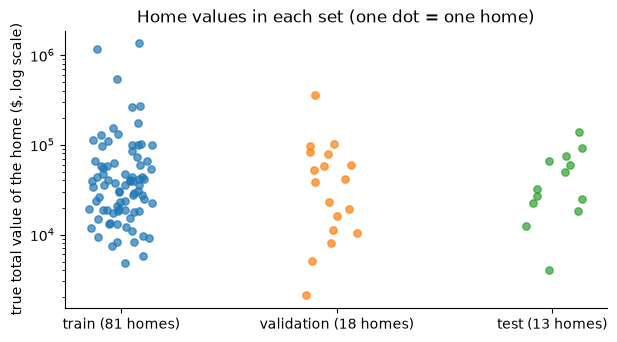

In [2]:
rows = {}
for k, d in S.items():
    h = d.groupby("Property_ID").agg(total=("true_total_value", "first"), items=("items_in_home", "first"))
    cov = d["documented_value"] / d["true_total_value"]
    rows[k] = {"homes": len(h), "rows": len(d), "home value: mean ($)": h.total.mean(), "median ($)": h.total.median(), "max ($)": h.total.max(),
               "top-1 share of set total (%)": 100 * h.total.max() / h.total.sum(), "items per home: median": h["items"].median(), "items per home: max": h["items"].max(),
               "basket coverage: median (%)": 100 * cov.median(), "rows where basket = whole home": int(np.isclose(d["documented_value"], d["true_total_value"]).sum())}
comp = pd.DataFrame(rows).T
display(comp.style.format({"home value: mean ($)": "{:,.0f}", "median ($)": "{:,.0f}", "max ($)": "{:,.0f}", "top-1 share of set total (%)": "{:.1f}", "basket coverage: median (%)": "{:.1f}"}, precision=0))

per_n = pd.concat({k: pd.DataFrame({"homes": d.groupby("n_documented").Property_ID.nunique(), "rows": d.groupby("n_documented").size(),
                                    "median basket coverage (%)": 100 * (d["documented_value"] / d["true_total_value"]).groupby(d["n_documented"]).median()}) for k, d in S.items()}, axis=1)
print("homes, rows and basket coverage by N and set:")
display(per_n.round(1))

fig, ax = plt.subplots()
for i, (k, d) in enumerate(S.items()):
    v = d.groupby("Property_ID").true_total_value.first().values
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.15, 0.15, len(v)), v, alpha=0.7, s=28)
ax.set_xticks(range(3))
ax.set_xticklabels([f"{k} ({d.Property_ID.nunique()} homes)" for k, d in S.items()])
ax.set_yscale("log")
ax.set_ylabel("true total value of the home ($, log scale)")
ax.set_title("Home values in each set (one dot = one home)")
plt.show()

## 3. Audit B - bias and error by set

The column `pred / true` is the sum of the ensemble predictions divided by the sum of the true values, where a value below 1 means under-prediction. The columns `median relative error` and `70th-pct relative error` are based on `|true - pred| / pred`, and the 70th percentile is the margin that would give exactly 70% **on that set**, so it is directly comparable with the frozen margin. Train is in-sample because the models were fitted on it.

train                                  \
             pred / true   MAE ($) median rel. error (%)   
n_documented                                               
10                  0.69  33962.69                 17.86   
20                  0.68  37824.43                  7.57   
30                  0.74  37546.23                  5.17   
50                  0.83  21585.23                  3.04   

                                                                     \
             70th-pct rel. error (%) success with frozen margin (%)   
n_documented                                                          
10                             42.01                          91.11   
20                             18.93                          86.67   
30                             15.94                          88.57   
50                              6.33                          91.54   

              validation                                  \
             pred / true   MAE ($) median rel. error (%)   
n_documented                                               
10                  0.65  37444.74                 56.27   
20                  0.80  36636.74                 36.90   
30                  0.80  36182.32                 24.62   
50                  0.82  33953.72                 21.07   

                                                                     \
             70th-pct rel. error (%) success with frozen margin (%)   
n_documented                                                          
10                             82.78                          73.33   
20                             51.11                          67.69   
30                             42.58                          68.89   
50                             59.03                          70.00   

                    test                                  \
             pred / true   MAE ($) median rel. error (%)   
n_documented                                               
10                  0.97  22716.13                 38.63   
20                  1.03  18901.89                 22.97   
30                  1.01  17506.35                 24.67   
50                  0.99  11118.22                 19.64   

                                                                     
             70th-pct rel. error (%) success with frozen margin (%)  
n_documented                                                         
10                             69.60                          84.62  
20                             49.30                          77.78  
30                             26.26                          96.00  
50                             23.80                         100.00

all N together:


,train,validation,test
pred / true,0.72,0.76,1.00
MAE ($),34199.65,36514.05,19543.77
median rel. error (%),9.09,39.92,25.98
70th-pct rel. error (%),23.87,68.67,43.56
success with frozen margin (%),89.42,70.43,86.00


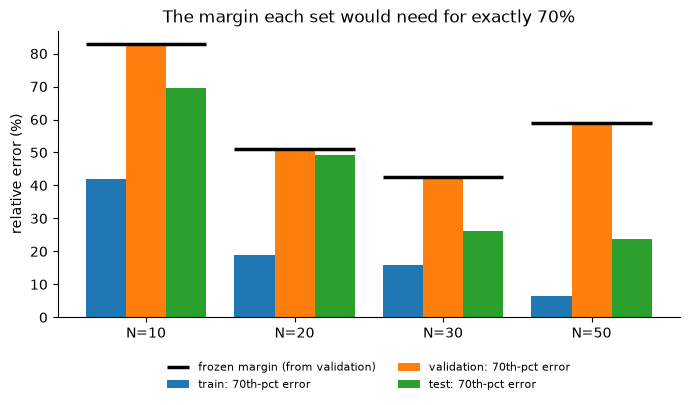

In [3]:
def stats(d):
    g = d.groupby("n_documented")
    return pd.DataFrame({"pred / true": g.apply(lambda x: x.ens.sum() / x.true_total_value.sum()), "MAE ($)": g.apply(lambda x: mean_absolute_error(x.true_total_value, x.ens)),
                         "median rel. error (%)": 100 * g.rel.median(), "70th-pct rel. error (%)": 100 * g.rel.quantile(CONF), "success with frozen margin (%)": 100 * g.inside.mean()})
bias = pd.concat({k: stats(d) for k, d in S.items()}, axis=1)
display(bias.round(2))
allrow = pd.DataFrame({k: {"pred / true": d.ens.sum() / d.true_total_value.sum(), "MAE ($)": mean_absolute_error(d.true_total_value, d.ens), "median rel. error (%)": 100 * d.rel.median(),
                           "70th-pct rel. error (%)": 100 * d.rel.quantile(CONF), "success with frozen margin (%)": 100 * d.inside.mean()} for k, d in S.items()})
print("all N together:")
display(allrow.round(2))

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(NS))
w_ = 0.27
for j, (k, d) in enumerate(S.items()): ax.bar(x + (j - 1) * w_, 100 * d.groupby("n_documented").rel.quantile(CONF).reindex(NS), w_, label=f"{k}: 70th-pct error")
for xi, n in zip(x, NS):                                   # frozen margin: one black line across the three bars of each N
    ax.hlines(100 * MARGIN[n], xi - 1.5 * w_, xi + 1.5 * w_, colors="k", linewidth=2.5, label="frozen margin (from validation)" if xi == 0 else None)
ax.set_xticks(x)
ax.set_xticklabels([f"N={n}" for n in NS])
ax.set_ylabel("relative error (%)")
ax.set_title("The margin each set would need for exactly 70%")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)       # legend below the plot: it no longer covers the bars or the title
fig.tight_layout()
plt.show()

## 4. Audit C - which homes set the validation margin?

The frozen margin of each N is the 70th percentile of the validation relative errors. With only 18 validation homes (and 5 rows per home and N) a single home can move it. For every validation home the margins are **recomputed without that home** and the change is reported (leave-one-home-out). The column `true value` shows how large the influential homes are.

In [4]:
val = S["validation"]
def margins(d): return d.groupby("n_documented").rel.quantile(CONF).reindex(NS)
full = margins(val)
rows = []
for pid, g in val.groupby("Property_ID"):
    m = margins(val[val.Property_ID != pid])
    rows.append({"home": pid, "true value ($)": g.true_total_value.iloc[0], "items": g.items_in_home.iloc[0], "pred / true": g.ens.sum() / g.true_total_value.sum(),
                 **{f"margin N={n} without it (%)": 100 * m[n] for n in NS}, "max change (pts)": 100 * (m - full).abs().max()})
infl = pd.DataFrame(rows).sort_values("max change (pts)", ascending=False).reset_index(drop=True)
print("frozen validation margins (%):", (100 * full).round(1).to_dict())
display(infl.head(6).round(2))

by_val = val.groupby("Property_ID").true_total_value.first().sort_values(ascending=False).index
alt = pd.DataFrame({"all 18 validation homes (frozen)": 100 * full,
                    "without the largest home": 100 * margins(val[~val.Property_ID.isin(by_val[:1])]),
                    "without the 3 largest homes": 100 * margins(val[~val.Property_ID.isin(by_val[:3])])}).T
alt.columns = [f"N={n}" for n in NS]
print("margins (%) when the largest validation homes are removed (diagnostic only - the frozen margins are NOT changed):")
display(alt.round(1))
print("largest validation homes ($):", val.groupby("Property_ID").true_total_value.first().sort_values(ascending=False).head(3).round(0).to_dict())

frozen validation margins (%): {10: 82.8, 20: 51.1, 30: 42.6, 50: 59.0}


,home,true value ($),items,pred / true,margin N=10 without it (%),margin N=20 without it (%),margin N=30 without it (%),margin N=50 without it (%),max change (pts)
0,PRP-000275,2100.0,69,9.54,73.61,50.29,32.54,22.58,36.45
1,PRP-000176,360420.0,116,0.37,73.61,50.29,32.54,22.58,36.45
2,PRP-000734,78138.0,52,0.91,82.78,51.11,43.53,74.42,15.39
3,PRP-000545,23090.0,63,0.99,82.78,59.52,43.53,74.42,15.39
4,PRP-000385,52847.0,73,0.82,82.78,59.52,43.53,74.42,15.39
5,PRP-000324,103191.0,51,0.74,73.61,53.63,43.01,74.42,15.39


margins (%) when the largest validation homes are removed (diagnostic only - the frozen margins are NOT changed):


,N=10,N=20,N=30,N=50
all 18 validation homes (frozen),82.8,51.1,42.6,59.0
without the largest home,73.6,50.3,32.5,22.6
without the 3 largest homes,66.8,50.5,41.4,28.1


largest validation homes ($): {'PRP-000176': 360420.0, 'PRP-000324': 103191.0, 'PRP-000757': 97153.0}


## 5. Sampling test 1 - how uncertain is the margin itself?

**Bootstrap of the validation homes:** 18 homes are drawn **with replacement** (all rows of a home go together), the margin of every N is recomputed, and this is repeated 2,000 times. The spread shows how much the margin depends on *which* homes happen to be in the validation set, and a wide spread means that the frozen margin is a noisy estimate.

,frozen margin (%),bootstrap median (%),5th pct (%),95th pct (%),95th / 5th
N=10,82.8,82.8,58.0,100.9,1.7
N=20,51.1,51.1,37.3,89.3,2.4
N=30,42.6,42.6,21.9,89.6,4.1
N=50,59.0,53.1,6.0,90.3,15.0


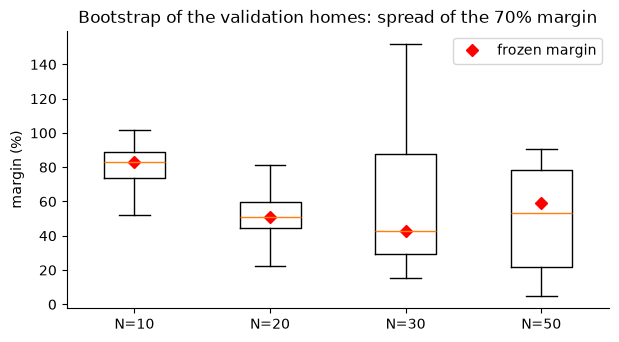

In [5]:
B = 2000
homes = val.Property_ID.unique()
idx = {p: np.where(val.Property_ID.values == p)[0] for p in homes}
bm = np.empty((B, len(NS)))
for b in range(B):
    pick = rng.choice(homes, size=len(homes), replace=True)
    d = val.iloc[np.concatenate([idx[p] for p in pick])]
    bm[b] = margins(d).values
bm = pd.DataFrame(100 * bm, columns=[f"N={n}" for n in NS])
res = pd.DataFrame({"frozen margin (%)": 100 * MARGIN.values, "bootstrap median (%)": bm.median(), "5th pct (%)": bm.quantile(0.05), "95th pct (%)": bm.quantile(0.95)}, index=bm.columns)
res["95th / 5th"] = res["95th pct (%)"] / res["5th pct (%)"]
display(res.round(1))

fig, ax = plt.subplots()
ax.boxplot([bm[c] for c in bm.columns], showfliers=False)
ax.set_xticklabels(bm.columns)
ax.plot(range(1, len(NS) + 1), 100 * MARGIN.values, "rD", label="frozen margin")
ax.set_ylabel("margin (%)")
ax.set_title("Bootstrap of the validation homes: spread of the 70% margin")
ax.legend()
plt.show()

## 6. Sampling test 2 - what would the test rate be under other splits?

The two final models never saw the validation **or** the test homes, so the 31 homes (18 validation and 13 test) are exchangeable out-of-sample homes. They are **re-split at random 2,000 times** (18 for calibration and 13 for evaluation, always whole homes), the margin per N is learned on the 18 and the success rate is measured on the 13. This is the same procedure as `04_ky_ensemble_and_intervals` (validation) and `05_ky_test_evaluation` (test), but with a different draw of homes each time.

This shows what a test success rate looks like when only the choice of homes changes. The real result of `05_ky_test_evaluation` is marked on the plot.

,actual test result,re-split mean,re-split 5th pct,re-split 95th pct,share of re-splits >= actual (%),share of re-splits >= 70% (%)
all,86.0,69.1,47.5,90.3,12.6,48.2
N=10,84.6,68.8,43.1,90.8,15.2,49.0
N=20,77.8,68.9,39.9,95.0,33.4,52.1
N=30,96.0,70.3,37.1,100.0,16.1,52.4
N=50,100.0,68.1,13.3,100.0,31.2,51.4


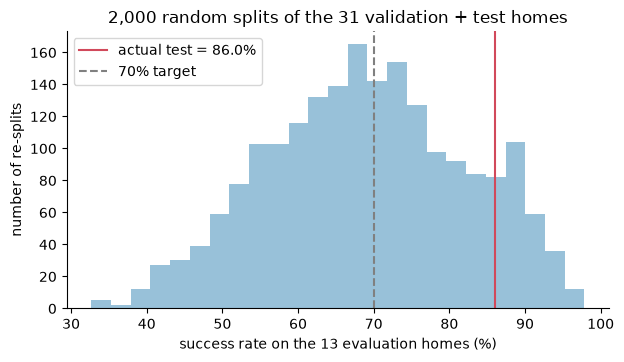

average margin learned on the 18 calibration homes (%): [75.1, 50.9, 34.9, 37.1]  vs frozen [82.8, 51.1, 42.6, 59.0]


In [6]:
pool = pd.concat([S["validation"], S["test"]], ignore_index=True)
pool_homes = pool.Property_ID.unique()
n_cal = S["validation"].Property_ID.nunique()
n_eval = S["test"].Property_ID.nunique()
pidx = {p: np.where(pool.Property_ID.values == p)[0] for p in pool_homes}
actual = {"all": 100 * S["test"].inside.mean(), **{n: 100 * S["test"][S["test"].n_documented == n].inside.mean() for n in NS}}
R = 2000
rate = np.full((R, 1 + len(NS)), np.nan)
mar = np.full((R, len(NS)), np.nan)
for r in range(R):
    perm = rng.permutation(pool_homes)
    cal = pool.iloc[np.concatenate([pidx[p] for p in perm[:n_cal]])]
    ev = pool.iloc[np.concatenate([pidx[p] for p in perm[n_cal:]])].copy()
    m = margins(cal)
    mar[r] = m.values
    mm = ev.n_documented.map(m)
    ok = (ev.true_total_value >= ev.ens * (1 - mm)) & (ev.true_total_value <= ev.ens * (1 + mm)) & mm.notna()
    ev = ev.assign(ok=ok, has=mm.notna())
    rate[r, 0] = 100 * ev.ok.sum() / max(ev.has.sum(), 1)
    for j, n in enumerate(NS):
        e = ev[(ev.n_documented == n) & ev.has]
        rate[r, 1 + j] = 100 * e.ok.mean() if len(e) else np.nan
rate = pd.DataFrame(rate, columns=["all"] + [f"N={n}" for n in NS])
summ = pd.DataFrame({"actual test result": [actual["all"]] + [actual[n] for n in NS], "re-split mean": rate.mean(), "re-split 5th pct": rate.quantile(0.05), "re-split 95th pct": rate.quantile(0.95),
                     "share of re-splits >= actual (%)": [100 * (rate[c] >= a).mean() for c, a in zip(rate.columns, [actual["all"]] + [actual[n] for n in NS])],
                     "share of re-splits >= 70% (%)": 100 * (rate >= 70).mean()}, index=rate.columns)
display(summ.round(1))

fig, ax = plt.subplots()
ax.hist(rate["all"].dropna(), bins=25, color="#98c1d9")
ax.axvline(actual["all"], color="#d1495b", label=f"actual test = {actual['all']:.1f}%")
ax.axvline(70, color="grey", ls="--", label="70% target")
ax.set_xlabel("success rate on the 13 evaluation homes (%)")
ax.set_ylabel("number of re-splits")
ax.set_title("2,000 random splits of the 31 validation + test homes")
ax.legend()
plt.show()
print(f"average margin learned on the 18 calibration homes (%): {(100 * np.nanmean(mar, axis=0)).round(1).tolist()}  vs frozen {(100 * MARGIN.values).round(1).tolist()}")

## 7. Sampling test 3 - how uncertain is the test success rate?

**Bootstrap of the test homes** (13 homes drawn with replacement, 2,000 times, frozen margins unchanged) gives a 95% interval for the success rate that `05_ky_test_evaluation` reports. If the interval is wide and includes values far from 86%, the number says little about other homes. The same is done at household level (the average of each home's own hit rate).

In [7]:
tst = S["test"]
th = tst.Property_ID.unique()
tidx = {p: np.where(tst.Property_ID.values == p)[0] for p in th}
row_r, hh_r = [], []
for b in range(2000):
    pick = rng.choice(th, size=len(th), replace=True)
    d = tst.iloc[np.concatenate([tidx[p] for p in pick])]
    row_r.append(100 * d.inside.mean())
    hh_r.append(100 * d.assign(h=np.repeat(np.arange(len(pick)), [len(tidx[p]) for p in pick])).groupby("h").inside.mean().mean())
ci = pd.DataFrame({"actual (%)": [100 * tst.inside.mean(), 100 * tst.groupby("Property_ID").inside.mean().mean()],
                   "bootstrap 2.5th pct": [np.percentile(row_r, 2.5), np.percentile(hh_r, 2.5)], "bootstrap 97.5th pct": [np.percentile(row_r, 97.5), np.percentile(hh_r, 97.5)]}, index=["row level", "household level"])
display(ci.round(1))
print("test homes by number of rows:", tst.groupby("Property_ID").size().value_counts().sort_index().to_dict(), "| homes per N:", tst.groupby("n_documented").Property_ID.nunique().to_dict())
print("N = 50 has", tst[tst.n_documented == 50].Property_ID.nunique(), "test homes and", int(tst[tst.n_documented == 50].inside.sum()), "of", int((tst.n_documented == 50).sum()), "rows inside: a 100% rate from 3 homes carries almost no information.")

,actual (%),bootstrap 2.5th pct,bootstrap 97.5th pct
row level,86.0,73.3,96.7
household level,87.6,77.0,96.4


test homes by number of rows: {5: 4, 10: 4, 15: 2, 20: 3} | homes per N: {10: 13, 20: 9, 30: 5, 50: 3}
N = 50 has 3 test homes and 15 of 15 rows inside: a 100% rate from 3 homes carries almost no information.


## 8. How much can each basket's success rate be believed?

A success rate per basket is only as reliable as the number of **homes** behind it, because the rows of one home are almost copies of each other and the real sample size is therefore the number of homes and not the number of rows. This section puts a **confidence interval** around the success rate of every basket, at two confidence levels, and asks whether the high test rates could simply be luck. Nothing is trained or tuned, and the frozen margins are not changed.

Three views of the same question:
1. **Test rows with the frozen margins (`05_ky_test_evaluation`):** The rate and a bootstrap interval obtained by resampling the **test homes** (all rows of a home together). With 5 and 3 test homes at N = 30 and N = 50 this interval is unreliable, because when every home hits every row the resampling cannot vary at all.
2. **Random re-splits (Sampling test 2 above):** The share of the 2,000 random splits of the 31 validation and test homes whose success rate is **as high or higher** than the actual test rate. A share of 5% or less would mean that luck alone rarely gives a rate this high.
3. **All 31 out-of-sample homes pooled, with margins cross-fitted by home:** For every home the margin of each N is learned from the **other 30 homes**, so no home helps set its own margin, and that home's rows are checked. The pooled rate gets the same bootstrap interval. This uses more homes per basket than the test set alone, and the rate is not in-sample for the margin.

**Confidence levels:** The **70%** interval is the middle 70% of the bootstrap rates (15th to 85th percentile), and the **95%** interval runs from the 2.5th to the 97.5th percentile.

,test homes,test rate (%),test 70% interval,test 95% interval,re-splits as high or higher (%),31 homes: homes,31 homes: rate (%),31 homes: 70% interval,31 homes: 95% interval,95% interval contains 70%
basket,,,,,,,,,,
N=10,13,84.6,75.4-93.8,64.6-100.0,15.2,31,70.3,62.6-78.1,54.8-84.5,yes
N=20,9,77.8,66.7-88.9,53.3-100.0,33.4,22,69.1,60.0-78.2,51.8-84.5,yes
N=30,5,96.0,92.0-100.0,88.0-100.0,16.1,14,70.0,58.6-81.4,48.6-90.0,yes
N=50,3,100.0,100.0-100.0,100.0-100.0,31.2,9,66.7,53.3-82.2,35.6-95.6,yes
ALL,13,86.0,80.0-92.3,73.9-96.7,12.6,31,69.5,62.8-76.5,56.0-81.9,yes


a test-only bootstrap with 5 or fewer homes (N = 30, N = 50) is unreliable, and N = 50 has 3 test homes


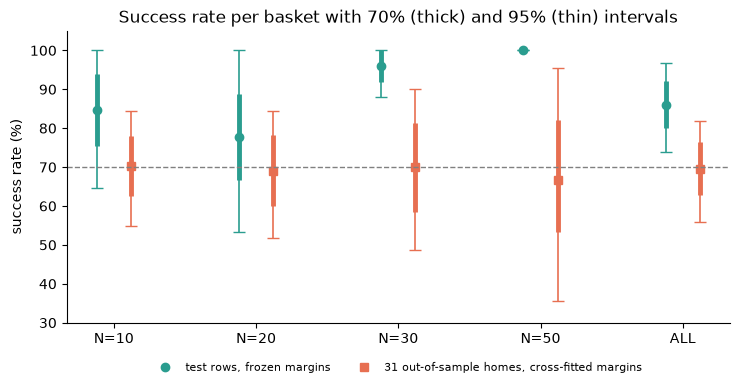

In [8]:
rng2 = np.random.default_rng(7)                       # separate generator: the numbers of the sections above do not depend on this cell
LEVELS = {"70%": (15, 85), "95%": (2.5, 97.5)}
B8 = 4000

def boot_interval(g, col):
    homes = g.Property_ID.unique()
    vals = {p: g.loc[g.Property_ID == p, col].values for p in homes}
    bs = [np.concatenate([vals[p] for p in rng2.choice(homes, len(homes))]).mean() * 100 for _ in range(B8)]
    return {lvl: (float(np.percentile(bs, lo)), float(np.percentile(bs, hi))) for lvl, (lo, hi) in LEVELS.items()}

# view 1: test rows with the frozen margins
tst8 = S["test"].assign(hit=S["test"]["inside"].astype(float))
# view 3: the 31 out-of-sample homes (validation + test), the margin of each home learned from the other 30 homes
pool31 = pd.concat([S["validation"], S["test"]], ignore_index=True)[["Property_ID", "n_documented", "true_total_value", "ens", "rel"]].copy()
pool31["hit"] = np.nan
for h in pool31.Property_ID.unique():
    m = pool31[pool31.Property_ID != h].groupby("n_documented").rel.quantile(CONF)
    mask = pool31.Property_ID == h
    mm = pool31.loc[mask, "n_documented"].map(m)
    pool31.loc[mask, "hit"] = ((pool31.loc[mask, "true_total_value"] >= pool31.loc[mask, "ens"] * (1 - mm)) & (pool31.loc[mask, "true_total_value"] <= pool31.loc[mask, "ens"] * (1 + mm))).astype(float)

fmt = lambda t: f"{t[0]:.1f}-{t[1]:.1f}"
rows = []
for n in NS + ["ALL"]:
    gt = tst8 if n == "ALL" else tst8[tst8.n_documented == n]
    gp = pool31 if n == "ALL" else pool31[pool31.n_documented == n]
    it, ip = boot_interval(gt, "hit"), boot_interval(gp, "hit")
    key = "all" if n == "ALL" else f"N={n}"
    rows.append({"basket": "ALL" if n == "ALL" else f"N={n}",
                 "test homes": gt.Property_ID.nunique(), "test rate (%)": 100 * gt.hit.mean(),
                 "test 70% interval": fmt(it["70%"]), "test 95% interval": fmt(it["95%"]),
                 "re-splits as high or higher (%)": summ.loc[key, "share of re-splits >= actual (%)"],
                 "31 homes: homes": gp.Property_ID.nunique(), "31 homes: rate (%)": 100 * gp.hit.mean(),
                 "31 homes: 70% interval": fmt(ip["70%"]), "31 homes: 95% interval": fmt(ip["95%"]),
                 "95% interval contains 70%": "yes" if ip["95%"][0] <= 70 <= ip["95%"][1] else "no",
                 "_t": it, "_p": ip})
conf = pd.DataFrame(rows).set_index("basket")
display(conf.drop(columns=["_t", "_p"]).style.format({"test rate (%)": "{:.1f}", "re-splits as high or higher (%)": "{:.1f}", "31 homes: rate (%)": "{:.1f}"}))
print("a test-only bootstrap with 5 or fewer homes (N = 30, N = 50) is unreliable, and N = 50 has", int(conf.loc["N=50", "test homes"]), "test homes")

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(conf))
off = 0.12
def err(rate, ints, lvl): return np.clip(np.vstack([rate.values - np.array([t[lvl][0] for t in ints]), np.array([t[lvl][1] for t in ints]) - rate.values]), 0, None)
for lvl, lw, cap in [("95%", 1.2, 4), ("70%", 3.5, 0)]:
    ax.errorbar(x - off, conf["test rate (%)"], yerr=err(conf["test rate (%)"], conf["_t"], lvl), fmt="none", ecolor="#2a9d8f", elinewidth=lw, capsize=cap)
    ax.errorbar(x + off, conf["31 homes: rate (%)"], yerr=err(conf["31 homes: rate (%)"], conf["_p"], lvl), fmt="none", ecolor="#e76f51", elinewidth=lw, capsize=cap)
ax.plot(x - off, conf["test rate (%)"], "o", color="#2a9d8f", label="test rows, frozen margins")
ax.plot(x + off, conf["31 homes: rate (%)"], "s", color="#e76f51", label="31 out-of-sample homes, cross-fitted margins")
ax.axhline(70, color="grey", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(conf.index)
ax.set_ylabel("success rate (%)")
ax.set_ylim(30, 105)
ax.set_title("Success rate per basket with 70% (thick) and 95% (thin) intervals")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
fig.tight_layout()
plt.show()

### Reading section 8: how much each basket's success rate can be believed (numbers from the run above)

| basket | test homes | test rate | test 70% / 95% interval | re-splits as high or higher | 31 homes: rate | 31 homes: 70% / 95% interval |
|---|---|---|---|---|---|---|
| N=10 | 13 | 84.6% | 75.4-93.8 / 64.6-100 | 15.2% | 70.3% | 62.6-78.1 / 54.8-84.5 |
| N=20 | 9 | 77.8% | 66.7-88.9 / 53.3-100 | 33.4% | 69.1% | 60.0-78.2 / 51.8-84.5 |
| N=30 | 5 | 96.0% | 92.0-100 / 88.0-100 | 16.1% | 70.0% | 58.6-81.4 / 48.6-90.0 |
| N=50 | 3 | 100% | 100-100 / 100-100 | 31.2% | 66.7% | 53.3-82.2 / 35.6-95.6 |
| all | 13 | 86.0% | 80.0-92.3 / 73.9-96.7 | 12.6% | 69.5% | 62.8-76.5 / 56.0-81.9 |

1. **Can the high test rates be called luck? No, and the opposite cannot be said either.** The honest statement is that they are **consistent with the 70% target**.
2. **Test rows only:** The intervals of N = 30 and of all baskets together lie above 70% (and at the 70% level also the interval of N = 10), but they rest on 13, 9, 5 and 3 homes. For N = 50 all three homes hit every row, so resampling the homes cannot vary at all and the "100-100" interval is meaningless. A bootstrap of 5 or fewer homes (N = 30 and N = 50) should not be trusted.
3. **Random re-splits:** A test rate as high as the observed one occurs in 12.6% (all), 15.2% (N = 10), 33.4% (N = 20), 16.1% (N = 30) and 31.2% (N = 50) of the re-splits. None is at or below 5%, so luck alone readily produces these values and no basket's test rate is statistically unusual.
4. **31 out-of-sample homes with cross-fitted margins:** The rates are 70.3%, 69.1%, 70.0% and 66.7% (all 69.5%), and the 95% interval contains 70% in every basket. This is the best available estimate of the real rate, and it is about 70%.
5. **Which baskets are the most prone to luck?** N = 50 (3 test homes and 9 pooled homes) and N = 30 (5 test homes and 14 pooled homes) carry almost no information, and their pooled 95% intervals are 36-96% and 49-90%. N = 20 is the most ordinary result (77.8%, and a third of the re-splits do as well). N = 10 is the best supported basket (13 test homes and 31 pooled homes), and its test rate of 84.6% is high, but 15% of the re-splits do as well.
6. **The most plausible reason why the test rates are above 70% is a favourable draw of homes**, because the test homes are easier (see Audit A and Audit B). This is a reading of the evidence and not a proof.

**Limits of this section:** The bootstrap resamples whole homes and is only rough with so few homes. The margin of each home in view 3 is learned from the other homes' predictions, and the validation homes also chose the blend weight and the number of trees in `03_ky_modelling_xgboost_lightgbm` and `04_ky_ensemble_and_intervals`, so the pooled rates are slightly optimistic.

## 9. Summary: what explains the three bars (numbers from the run above)

Nothing was tuned or changed in this notebook.

1. **Validation is about 70% by construction.** The frozen margins are the 70th percentile of the validation relative errors, so applying them to the same validation rows gives 70.4%. It is not a result.
2. **Train is high because it is in-sample and the margins are wide.** The median relative error is 9.1% on train against 39.9% on validation (and 26.0% on test). The margin that a train home needs for 70% is 23.9% overall, but the frozen margins are 42.6% to 82.8%, so about 89% of the train rows fall inside.
3. **Two validation homes set the margins.** Leave-one-home-out shows that **PRP-000176** (true value $360,420, predicted at 0.37 of the truth) and **PRP-000275** (true total only $2,100 although it lists 69 items, predicted at 9.5 times the truth) each move the margins by up to 36 points. Without the largest home the N = 10 margin falls from 82.8% to 73.6%, the N = 30 margin from 42.6% to 32.5% and the N = 50 margin from 59.0% to 22.6%. PRP-000275 looks like a data-quality case that is worth checking at the source.
4. **The margin itself is very uncertain.** Bootstrapping the 18 validation homes gives 5th to 95th percentile ranges of 58% to 101% (N = 10), 37% to 89% (N = 20), 22% to 90% (N = 30) and 6% to 90% (N = 50). With 6 validation homes at N = 50, the frozen 59.0% is close to a coin flip.
5. **The test homes are easier.** The largest test home is $138,593 (validation $360,420 and train $1,349,866), the models are unbiased on them (pred / true is 1.00, against 0.76 on validation and 0.72 on train), and the baskets cover more of the home at N = 20 (median 64.5% against 49.0% on validation and 41.4% on train). Their 70th-percentile error is 43.6% overall, so the wide frozen margins over-cover.
6. **A good part of the test result is the draw of homes.** In 2,000 random splits of the 31 validation and test homes (18 calibrate and 13 evaluate) the average success rate is **69.1%** (5th to 95th percentile 47.5% to 90.3%), and 48.2% of the splits reach 70%. The actual test rate of 86.0% is higher than 87% of the re-splits (12.6% are as high or higher), which puts it on the lucky side but not at an extreme. The 95% bootstrap interval of the test rate itself is 73.3% to 96.7% at row level, so 70% is not far outside it.
7. **N = 30 and N = 50 on the test set carry almost no information.** They rest on 5 and 3 homes (25 and 15 rows), and 15 of 15 rows inside at N = 50 is a 100% rate from three homes.
8. **Confidence in the rate of each basket (section 8).** At the 95% level the pooled interval of every basket contains 70% (N = 10: 54.8-84.5, N = 20: 51.8-84.5, N = 30: 48.6-90.0, N = 50: 35.6-95.6, and all 31 homes 56.0-81.9 with a rate of 69.5%). A test rate as high as the observed one occurs in 12.6% to 33.4% of the random re-splits and never in 5% or fewer, so the high test rates can neither be called luck nor proven real, and they are consistent with 70%. N = 50 and N = 30 (3 and 5 test homes) are the least informative baskets and N = 10 is the best supported.

**Conclusion.** The pattern in the chart is explained by four things: validation is in-sample by construction, train is in-sample, the margins are set by two extreme validation homes and are very noisy, and the test homes are easy and unbiased and came from a lucky draw. It does **not** show that the intervals are good, because on the same models a different split of the validation and test homes gives about 69% on average with a wide range. The honest statement is that the 70% target can be neither confirmed nor rejected with 13 test homes.

**What would help (not done here):** More homes in validation and test, or cross-fitted and repeated splits on all 112 labelled homes, would make the estimates more stable. Margins fitted on a larger set than 18 validation homes would be less noisy, a check of PRP-000275 would clarify the data-quality question, and a bootstrap interval should be reported next to every success rate.